In [ ]:
# ============================================================
# PROJET DEEP LEARNING — PARTIE III : RNN / LSTM / GRU
# Dataset : IMDb (analyse de sentiment)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
from collections import Counter
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Fixer les seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")
print(f"PyTorch version : {torch.__version__}")

Device utilisé : cuda
PyTorch version : 2.10.0+cu128


In [ ]:
# ============================================================
# ÉTAPE 2 — Chargement du dataset IMDb
# ============================================================

# Téléchargement automatique via torchtext
import subprocess
subprocess.run(['pip', 'install', 'datasets', '-q'])

from datasets import load_dataset

print("Chargement du dataset IMDb...")
dataset = load_dataset('imdb')

print("\n=== INFOS DATASET ===")
print(f"Train : {len(dataset['train'])} critiques")
print(f"Test  : {len(dataset['test'])} critiques")
print(f"\nExemple de critique :")
print(f"Texte  : {dataset['train'][0]['text'][:200]}...")
print(f"Label  : {dataset['train'][0]['label']} "
      f"({'Positif' if dataset['train'][0]['label'] == 1 else 'Négatif'})")

print(f"\nDistribution des classes (Train) :")
labels = [x['label'] for x in dataset['train']]
print(f"Positif : {labels.count(1):,}")
print(f"Négatif : {labels.count(0):,}")

Chargement du dataset IMDb...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


=== INFOS DATASET ===
Train : 25000 critiques
Test  : 25000 critiques

Exemple de critique :
Texte  : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
Label  : 0 (Négatif)

Distribution des classes (Train) :
Positif : 12,500
Négatif : 12,500


In [ ]:
# ============================================================
# ÉTAPE 3 — Préparation des données
# Tokenisation, Vocabulaire, Padding
# ============================================================

# --- Paramètres ---
VOCAB_SIZE   = 10000   # On garde les 10,000 mots les plus fréquents
MAX_LEN      = 200     # Longueur maximale de chaque critique (en mots)
BATCH_SIZE   = 64

# --- Nettoyage du texte ---
def nettoyer_texte(texte):
    texte = texte.lower()                        # Minuscules
    texte = re.sub(r'<[^>]+>', '', texte)        # Supprimer HTML (<br/>)
    texte = re.sub(r'[^a-z\s]', '', texte)       # Garder lettres seulement
    texte = re.sub(r'\s+', ' ', texte).strip()   # Espaces multiples
    return texte

# --- Tokenisation simple ---
def tokeniser(texte):
    return nettoyer_texte(texte).split()

# --- Construire le vocabulaire ---
print("Construction du vocabulaire...")
compteur = Counter()
for exemple in dataset['train']:
    tokens = tokeniser(exemple['text'])
    compteur.update(tokens)

# Tokens spéciaux
PAD_TOKEN = '<PAD>'   # Pour remplir les séquences courtes
UNK_TOKEN = '<UNK>'   # Pour les mots hors vocabulaire

# Garder les VOCAB_SIZE mots les plus fréquents
mots_frequents = [mot for mot, _ in compteur.most_common(VOCAB_SIZE - 2)]
vocabulaire    = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for i, mot in enumerate(mots_frequents):
    vocabulaire[mot] = i + 2

print(f"Taille du vocabulaire : {len(vocabulaire):,} mots")
print(f"Exemples : {list(vocabulaire.items())[:10]}")

# --- Encoder un texte en indices ---
def encoder_texte(texte, vocab, max_len):
    tokens  = tokeniser(texte)[:max_len]    # Tronquer si trop long
    indices = [vocab.get(t, 1) for t in tokens]  # 1 = UNK si mot inconnu

    # Padding : remplir avec 0 si trop court
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))

    return indices

# --- Dataset PyTorch ---
class IMDbDataset(Dataset):
    def __init__(self, data):
        self.textes = [encoder_texte(x['text'], vocabulaire, MAX_LEN)
                       for x in data]
        self.labels = [x['label'] for x in data]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.textes[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float))

# --- Créer les datasets ---
print("\nCréation des datasets...")
train_val_dataset = IMDbDataset(dataset['train'])
test_dataset      = IMDbDataset(dataset['test'])

# Séparation Train / Validation
train_size = int(0.85 * len(train_val_dataset))
val_size   = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(
    train_val_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\n=== RÉSUMÉ ===")
print(f"Train      : {len(train_dataset):,} critiques")
print(f"Validation : {len(val_dataset):,} critiques")
print(f"Test       : {len(test_dataset):,} critiques")
print(f"Max longueur séquence : {MAX_LEN} mots")
print(f"Taille vocabulaire    : {VOCAB_SIZE:,} mots")

# --- Vérification ---
X_batch, y_batch = next(iter(train_loader))
print(f"\nShape d'un batch :")
print(f"  X : {X_batch.shape}  (batch_size × max_len)")
print(f"  y : {y_batch.shape}  (batch_size)")
print(f"\nExemple encodé (20 premiers indices) :")
print(f"  {X_batch[0][:20].tolist()}")

Construction du vocabulaire...
Taille du vocabulaire : 10,000 mots
Exemples : [('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9)]

Création des datasets...

=== RÉSUMÉ ===
Train      : 21,250 critiques
Validation : 3,750 critiques
Test       : 25,000 critiques
Max longueur séquence : 200 mots
Taille vocabulaire    : 10,000 mots

Shape d'un batch :
  X : torch.Size([64, 200])  (batch_size × max_len)
  y : torch.Size([64])  (batch_size)

Exemple encodé (20 premiers indices) :
  [1758, 1966, 7363, 3, 103, 2, 197, 562, 1725, 635, 298, 2, 2587, 534, 503, 5, 562, 1725, 3, 1]


In [ ]:
# ============================================================
# ÉTAPE 4 — Implémentation RNN, LSTM, GRU
# ============================================================

# ── Classe générique qui fonctionne pour les 3 modèles ─────
class ModeleSequentiel(nn.Module):

    def __init__(self, type_modele='LSTM', vocab_size=10000,
                 embed_dim=128, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super(ModeleSequentiel, self).__init__()

        self.type_modele = type_modele

        # ── Couche Embedding ──
        # Convertit chaque indice de mot en vecteur dense
        # Ex: mot "film" (indice 42) → vecteur de 128 valeurs
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )

        # ── Couche Récurrente (RNN / LSTM / GRU) ──
        if type_modele == 'RNN':
            self.rnn = nn.RNN(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,       # (batch, seq, features)
                dropout=dropout,
                bidirectional=True      # Lit dans les 2 sens
            )
        elif type_modele == 'LSTM':
            self.rnn = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout,
                bidirectional=True
            )
        elif type_modele == 'GRU':
            self.rnn = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout,
                bidirectional=True
            )

        # ── Couches de Classification ──
        # bidirectional=True → hidden_size × 2
        self.fc1     = nn.Linear(hidden_size * 2, 64)
        self.fc2     = nn.Linear(64, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()

    def forward(self, x):
        # x shape : (batch, seq_len)

        # Embedding : indices → vecteurs
        embedded = self.dropout(self.embedding(x))
        # embedded shape : (batch, seq_len, embed_dim)

        # Passage dans le modèle récurrent
        if self.type_modele == 'LSTM':
            output, (hidden, cell) = self.rnn(embedded)
            # Pour LSTM : on prend les derniers états cachés
            # des 2 directions (forward + backward)
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            output, hidden = self.rnn(embedded)
            if hidden.dim() == 3:
                hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
            else:
                hidden = hidden.squeeze(0)

        # Classification
        x = self.dropout(self.relu(self.fc1(hidden)))
        x = self.fc2(x)
        return x


# --- Instancier les 3 modèles ---
model_rnn  = ModeleSequentiel('RNN').to(device)
model_lstm = ModeleSequentiel('LSTM').to(device)
model_gru  = ModeleSequentiel('GRU').to(device)

# --- Vérifier les dimensions ---
print("=== VÉRIFICATION DES DIMENSIONS ===\n")
test_input = torch.randint(0, 10000, (2, 200)).to(device)

with torch.no_grad():
    out_rnn  = model_rnn(test_input)
    out_lstm = model_lstm(test_input)
    out_gru  = model_gru(test_input)

print(f"Input shape  : {test_input.shape}")
print(f"RNN  output  : {out_rnn.shape}  ✅")
print(f"LSTM output  : {out_lstm.shape} ✅")
print(f"GRU  output  : {out_gru.shape}  ✅")

# --- Compter les paramètres ---
print("\n=== PARAMÈTRES PAR MODÈLE ===\n")
for nom, model in [('RNN', model_rnn),
                   ('LSTM', model_lstm),
                   ('GRU', model_gru)]:
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{nom}  : {params:,} paramètres")

=== VÉRIFICATION DES DIMENSIONS ===

Input shape  : torch.Size([2, 200])
RNN  output  : torch.Size([2, 1])  ✅
LSTM output  : torch.Size([2, 1]) ✅
GRU  output  : torch.Size([2, 1])  ✅

=== PARAMÈTRES PAR MODÈLE ===

RNN  : 1,461,377 paramètres
LSTM  : 1,955,969 paramètres
GRU  : 1,791,105 paramètres


In [ ]:
# ============================================================
# ÉTAPE 5 — Entraînement des 3 modèles + Sauvegarde
# ============================================================

def entrainer_modele(model, nom, epochs=10, patience=3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,
                                 weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', patience=2, factor=0.5)

    hist = {'train_loss': [], 'val_loss': [],
            'train_acc' : [], 'val_acc' : []}
    meilleure_loss   = float('inf')
    meilleur_state   = None
    patience_counter = 0

    print(f"\n{'='*55}")
    print(f"  Entraînement {nom}")
    print(f"{'='*55}")

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch).squeeze()
            loss   = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss    += loss.item()
            preds          = (torch.sigmoid(logits) > 0.5).float()
            train_correct += (preds == y_batch).sum().item()

        train_loss /= len(train_loader)
        train_acc   = train_correct / len(train_dataset)

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                logits  = model(X_batch).squeeze()
                loss    = criterion(logits, y_batch)
                val_loss    += loss.item()
                preds        = (torch.sigmoid(logits) > 0.5).float()
                val_correct += (preds == y_batch).sum().item()

        val_loss /= len(val_loader)
        val_acc   = val_correct / len(val_dataset)
        scheduler.step(val_loss)

        if val_loss < meilleure_loss:
            meilleure_loss   = val_loss
            meilleur_state   = {k: v.clone()
                                for k, v in model.state_dict().items()}
            patience_counter = 0
            save_msg         = " <- sauvegarde"
        else:
            patience_counter += 1
            save_msg         = ""

        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['train_acc'].append(train_acc)
        hist['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}{save_msg}")

        if patience_counter >= patience:
            print(f"Early stopping a l'epoque {epoch+1}")
            break

    model.load_state_dict(meilleur_state)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch).squeeze()
            preds   = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    resultats = {
        'historique': hist,
        'accuracy'  : accuracy_score(all_labels, all_preds),
        'f1'        : f1_score(all_labels, all_preds),
        'recall'    : recall_score(all_labels, all_preds),
        'precision' : precision_score(all_labels, all_preds),
        'epochs'    : len(hist['val_loss']),
        'preds'     : all_preds,
        'labels'    : all_labels
    }
    return resultats

# --- Entraîner les 3 modèles ---
res_rnn  = entrainer_modele(model_rnn,  'RNN')
res_lstm = entrainer_modele(model_lstm, 'LSTM')
res_gru  = entrainer_modele(model_gru,  'GRU')

# --- Sauvegarde automatique ---
import pickle
with open('res_rnn.pkl',  'wb') as f: pickle.dump(res_rnn,  f)
with open('res_lstm.pkl', 'wb') as f: pickle.dump(res_lstm, f)
with open('res_gru.pkl',  'wb') as f: pickle.dump(res_gru,  f)
print("\nResultats sauvegardes ! On ne perdra plus rien !")


  Entraînement RNN
Epoch  1/10 | Train Loss: 0.6039 | Train Acc: 0.6823 | Val Loss: 0.6053 | Val Acc: 0.6707 <- sauvegarde
Epoch  2/10 | Train Loss: 0.5915 | Train Acc: 0.6936 | Val Loss: 0.6978 | Val Acc: 0.6299
Epoch  3/10 | Train Loss: 0.6033 | Train Acc: 0.6816 | Val Loss: 0.6097 | Val Acc: 0.6683
Epoch  4/10 | Train Loss: 0.5896 | Train Acc: 0.6920 | Val Loss: 0.5974 | Val Acc: 0.7101 <- sauvegarde
Epoch  5/10 | Train Loss: 0.5661 | Train Acc: 0.7121 | Val Loss: 0.6658 | Val Acc: 0.6045
Epoch  6/10 | Train Loss: 0.5573 | Train Acc: 0.7251 | Val Loss: 0.5443 | Val Acc: 0.7467 <- sauvegarde
Epoch  7/10 | Train Loss: 0.5202 | Train Acc: 0.7559 | Val Loss: 0.5306 | Val Acc: 0.7539 <- sauvegarde
Epoch  8/10 | Train Loss: 0.5244 | Train Acc: 0.7457 | Val Loss: 0.5771 | Val Acc: 0.7267
Epoch  9/10 | Train Loss: 0.4980 | Train Acc: 0.7663 | Val Loss: 0.5745 | Val Acc: 0.7547
Epoch 10/10 | Train Loss: 0.4630 | Train Acc: 0.7992 | Val Loss: 0.5291 | Val Acc: 0.7739 <- sauvegarde

  Entraîn


=== TABLEAU COMPARATIF RNN vs LSTM vs GRU ===

Modele       Accuracy   F1-Score     Recall  Precision    Epoques
------------------------------------------------------------
RNN            0.7723     0.7811     0.8122     0.7522         10
LSTM           0.8584     0.8635     0.8959     0.8333          5
GRU            0.8633     0.8585     0.8294     0.8897          4


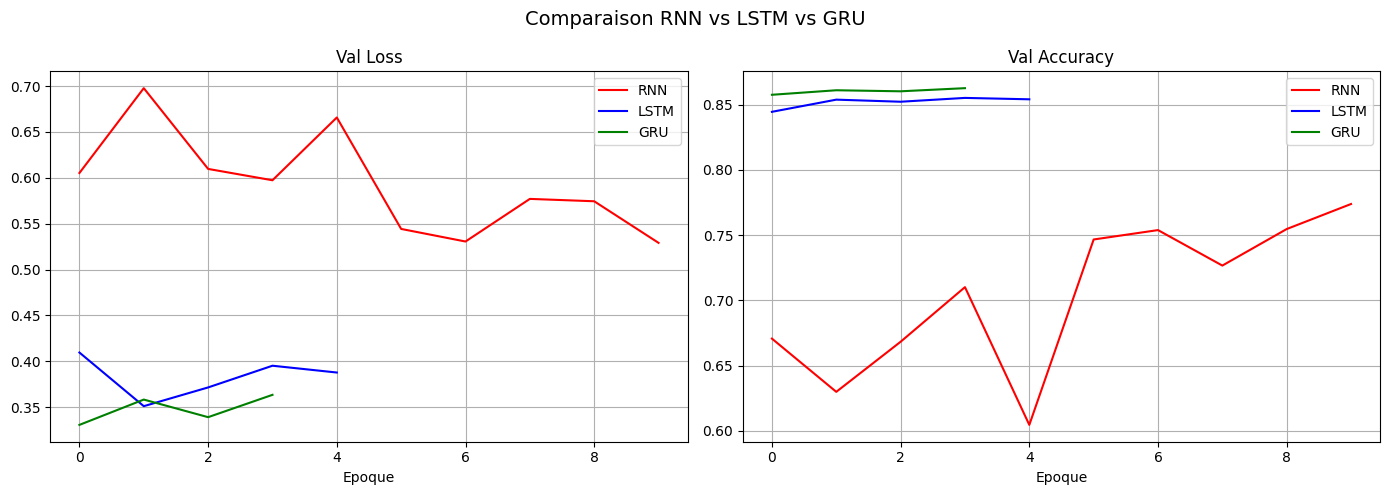

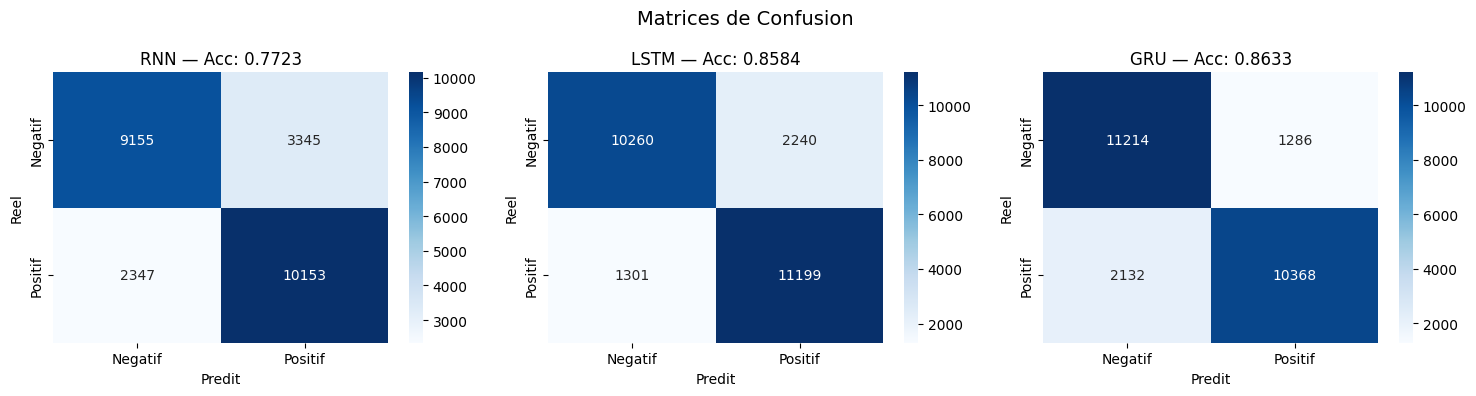


=== RAPPORT DETAILLE ===

--- RNN ---
              precision    recall  f1-score   support

     Negatif       0.80      0.73      0.76     12500
     Positif       0.75      0.81      0.78     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000


--- LSTM ---
              precision    recall  f1-score   support

     Negatif       0.89      0.82      0.85     12500
     Positif       0.83      0.90      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


--- GRU ---
              precision    recall  f1-score   support

     Negatif       0.84      0.90      0.87     12500
     Positif       0.89      0.83      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted

In [ ]:
# ============================================================
# ÉTAPE 6 — Comparaison + Courbes + Matrice de confusion
# ============================================================

# Tableau comparatif
print("\n=== TABLEAU COMPARATIF RNN vs LSTM vs GRU ===\n")
print(f"{'Modele':<10} {'Accuracy':>10} {'F1-Score':>10} "
      f"{'Recall':>10} {'Precision':>10} {'Epoques':>10}")
print("-" * 60)
for nom, res in [('RNN', res_rnn), ('LSTM', res_lstm), ('GRU', res_gru)]:
    print(f"{nom:<10} {res['accuracy']:>10.4f} {res['f1']:>10.4f} "
          f"{res['recall']:>10.4f} {res['precision']:>10.4f} "
          f"{res['epochs']:>10}")

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison RNN vs LSTM vs GRU", fontsize=14)
couleurs = {'RNN': 'red', 'LSTM': 'blue', 'GRU': 'green'}

for nom, res in [('RNN', res_rnn), ('LSTM', res_lstm), ('GRU', res_gru)]:
    axes[0].plot(res['historique']['val_loss'],
                 label=nom, color=couleurs[nom])
    axes[1].plot(res['historique']['val_acc'],
                 label=nom, color=couleurs[nom])

axes[0].set_title("Val Loss")
axes[0].set_xlabel("Epoque")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Val Accuracy")
axes[1].set_xlabel("Epoque")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Matrices de Confusion", fontsize=14)
for ax, (nom, res) in zip(axes, [('RNN',  res_rnn),
                                  ('LSTM', res_lstm),
                                  ('GRU',  res_gru)]):
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negatif', 'Positif'],
                yticklabels=['Negatif', 'Positif'])
    ax.set_title(f"{nom} — Acc: {res['accuracy']:.4f}")
    ax.set_ylabel("Reel")
    ax.set_xlabel("Predit")
plt.tight_layout()
plt.show()

# Rapport détaillé
print("\n=== RAPPORT DETAILLE ===")
for nom, res in [('RNN', res_rnn), ('LSTM', res_lstm), ('GRU', res_gru)]:
    print(f"\n--- {nom} ---")
    print(classification_report(res['labels'], res['preds'],
          target_names=['Negatif', 'Positif']))

=== POURQUOI LE GRADIENT CLIPPING ? ===

Dans les RNN, les gradients se multiplient à chaque timestep.
Sur 200 mots, le gradient peut exploser (valeurs énormes → NaN)
ou disparaître (valeurs nulles → le modèle n'apprend plus).

Le gradient clipping coupe les gradients trop grands :
  si ||gradient|| > max_norm → gradient = gradient × (max_norm / ||gradient||)



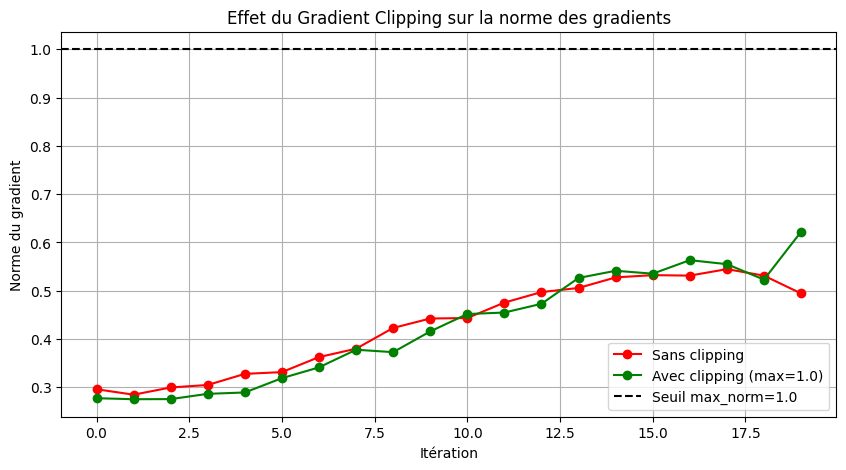

=== RÉSUMÉ ===
Norme max SANS clipping : 0.5447
Norme max AVEC clipping : 0.6220

Conclusion : le clipping maintient les gradients
sous le seuil 1.0 — stabilite garantie ✅


In [ ]:
# ============================================================
# ÉTAPE 7 — Illustration du Gradient Clipping
# ============================================================

print("=== POURQUOI LE GRADIENT CLIPPING ? ===")
print("""
Dans les RNN, les gradients se multiplient à chaque timestep.
Sur 200 mots, le gradient peut exploser (valeurs énormes → NaN)
ou disparaître (valeurs nulles → le modèle n'apprend plus).

Le gradient clipping coupe les gradients trop grands :
  si ||gradient|| > max_norm → gradient = gradient × (max_norm / ||gradient||)
""")

# --- Démonstration expérimentale ---
model_test    = ModeleSequentiel('RNN').to(device)
criterion     = nn.BCEWithLogitsLoss()
optimizer     = torch.optim.Adam(model_test.parameters(), lr=1e-3)

X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

# --- SANS gradient clipping ---
norms_sans = []
for _ in range(20):
    optimizer.zero_grad()
    loss = criterion(model_test(X_batch).squeeze(), y_batch)
    loss.backward()
    # Calculer la norme des gradients AVANT clipping
    total_norm = 0
    for p in model_test.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    norms_sans.append(total_norm ** 0.5)
    optimizer.step()

# --- AVEC gradient clipping ---
model_test2   = ModeleSequentiel('RNN').to(device)
optimizer2    = torch.optim.Adam(model_test2.parameters(), lr=1e-3)

norms_avec = []
for _ in range(20):
    optimizer2.zero_grad()
    loss = criterion(model_test2(X_batch).squeeze(), y_batch)
    loss.backward()
    # Clipping à max_norm=1.0
    torch.nn.utils.clip_grad_norm_(model_test2.parameters(), max_norm=1.0)
    # Calculer la norme APRÈS clipping
    total_norm = 0
    for p in model_test2.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    norms_avec.append(total_norm ** 0.5)
    optimizer2.step()

# --- Visualisation ---
plt.figure(figsize=(10, 5))
plt.plot(norms_sans, label='Sans clipping', color='red',   marker='o')
plt.plot(norms_avec, label='Avec clipping (max=1.0)',
                            color='green', marker='o')
plt.axhline(y=1.0, color='black', linestyle='--',
            label='Seuil max_norm=1.0')
plt.title("Effet du Gradient Clipping sur la norme des gradients")
plt.xlabel("Itération")
plt.ylabel("Norme du gradient")
plt.legend()
plt.grid(True)
plt.show()

print("=== RÉSUMÉ ===")
print(f"Norme max SANS clipping : {max(norms_sans):.4f}")
print(f"Norme max AVEC clipping : {max(norms_avec):.4f}")
print(f"\nConclusion : le clipping maintient les gradients")
print(f"sous le seuil 1.0 — stabilite garantie ✅")

In [ ]:
# ============================================================
# ÉTAPE 8 — Système Seq2Seq (Encodeur + Décodeur)
# Tâche : Inversion de séquence (démonstration)
# ============================================================

print("=== QU'EST-CE QU'UN SEQ2SEQ ? ===")
print("""
Un système Seq2Seq prend une séquence en entrée et produit
une séquence en sortie. Exemples :
  - Traduction : "I love films" → "J'adore les films"
  - Résumé     : article long → résumé court
  - Chatbot    : question → réponse

Architecture :
  ENCODEUR → lit la séquence entière → vecteur contexte
  DÉCODEUR → génère la séquence de sortie mot par mot
""")

# --- Données simples : inverser une séquence de chiffres ---
# Ex: [1,2,3,4,5] → [5,4,3,2,1]

VOCAB_SEQ  = 10   # Chiffres 0-9
SEQ_LEN    = 6    # Longueur des séquences
N_SAMPLES  = 3000 # Nombre d'exemples

def generer_donnees(n, seq_len, vocab):
    """Génère des paires (séquence, séquence inversée)"""
    sources = []
    cibles  = []
    for _ in range(n):
        seq = [random.randint(1, vocab-1) for _ in range(seq_len)]
        sources.append(seq)
        cibles.append(seq[::-1])  # Inverser la séquence
    return torch.tensor(sources), torch.tensor(cibles)

# Générer les données
X_seq, y_seq = generer_donnees(N_SAMPLES, SEQ_LEN, VOCAB_SEQ)

print(f"Exemple source : {X_seq[0].tolist()}")
print(f"Exemple cible  : {y_seq[0].tolist()} (inversé)")

# Split train/test
split      = int(0.8 * N_SAMPLES)
X_train_s  = X_seq[:split]
y_train_s  = y_seq[:split]
X_test_s   = X_seq[split:]
y_test_s   = y_seq[split:]

# DataLoader
seq_dataset     = torch.utils.data.TensorDataset(X_train_s, y_train_s)
seq_loader      = DataLoader(seq_dataset, batch_size=64, shuffle=True)

# ── Encodeur ───────────────────────────────────────────────
class Encodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super(Encodeur, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru       = nn.GRU(embed_dim, hidden_size, batch_first=True)

    def forward(self, x):
        embedded        = self.embedding(x)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden  # hidden = vecteur contexte

# ── Décodeur ───────────────────────────────────────────────
class Decodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super(Decodeur, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru       = nn.GRU(embed_dim, hidden_size, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        # x shape : (batch, 1) — un token à la fois
        embedded        = self.embedding(x.unsqueeze(1))
        output, hidden  = self.gru(embedded, hidden)
        prediction      = self.fc(output.squeeze(1))
        return prediction, hidden

# ── Seq2Seq ────────────────────────────────────────────────
class Seq2Seq(nn.Module):
    def __init__(self, encodeur, decodeur, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encodeur  = encodeur
        self.decodeur  = decodeur
        self.vocab_size = vocab_size

    def forward(self, src, tgt, teacher_forcing=0.5):
        batch_size = src.shape[0]
        tgt_len    = tgt.shape[1]
        outputs    = torch.zeros(batch_size, tgt_len,
                                 self.vocab_size).to(device)

        # Encoder la séquence source
        _, hidden = self.encodeur(src)

        # Premier token du décodeur
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decodeur(input_token, hidden)
            outputs[:, t]  = output

            # Teacher forcing : utiliser le vrai token ou la prédiction
            if random.random() < teacher_forcing:
                input_token = tgt[:, t]           # Vrai token
            else:
                input_token = output.argmax(1)    # Token prédit

        return outputs

# --- Instancier le modèle ---
EMBED_DIM   = 16
HIDDEN_SIZE = 64

encodeur  = Encodeur(VOCAB_SEQ, EMBED_DIM, HIDDEN_SIZE).to(device)
decodeur  = Decodeur(VOCAB_SEQ, EMBED_DIM, HIDDEN_SIZE).to(device)
seq2seq   = Seq2Seq(encodeur, decodeur, VOCAB_SEQ).to(device)

params = sum(p.numel() for p in seq2seq.parameters())
print(f"\nParametres Seq2Seq : {params:,}")
print("Architecture Seq2Seq instanciee !")

=== QU'EST-CE QU'UN SEQ2SEQ ? ===

Un système Seq2Seq prend une séquence en entrée et produit
une séquence en sortie. Exemples :
  - Traduction : "I love films" → "J'adore les films"
  - Résumé     : article long → résumé court
  - Chatbot    : question → réponse

Architecture :
  ENCODEUR → lit la séquence entière → vecteur contexte
  DÉCODEUR → génère la séquence de sortie mot par mot

Exemple source : [4, 4, 3, 6, 7, 3]
Exemple cible  : [3, 7, 6, 3, 4, 4] (inversé)

Parametres Seq2Seq : 32,458
Architecture Seq2Seq instanciee !


=== ENTRAÎNEMENT SEQ2SEQ ===

Epoch  5/30 | Loss: 0.0090
Epoch 10/30 | Loss: 0.0037
Epoch 15/30 | Loss: 0.0020
Epoch 20/30 | Loss: 0.0012
Epoch 25/30 | Loss: 0.0008
Epoch 30/30 | Loss: 0.0006


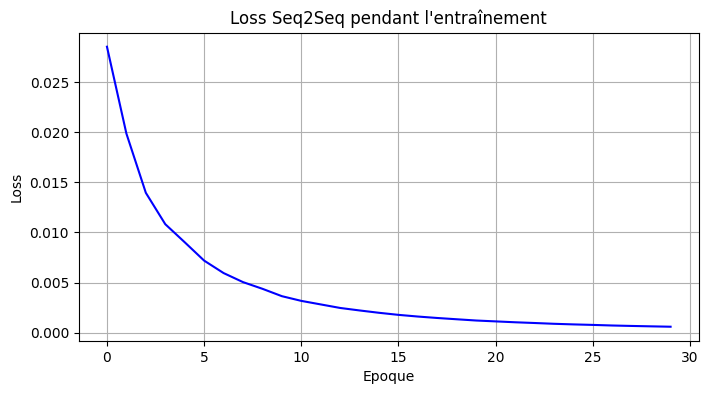

In [ ]:
# ============================================================
# ÉTAPE 9 — Entraînement Seq2Seq + Décodage
# ============================================================

# --- Entraînement ---
optimizer_seq = torch.optim.Adam(seq2seq.parameters(), lr=1e-3)
criterion_seq = nn.CrossEntropyLoss()

print("=== ENTRAÎNEMENT SEQ2SEQ ===\n")
losses = []

for epoch in range(30):
    seq2seq.train()
    total_loss = 0

    for X_batch, y_batch in seq_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_seq.zero_grad()
        outputs = seq2seq(X_batch, y_batch, teacher_forcing=0.5)

        # Reshape pour CrossEntropyLoss
        # outputs : (batch, seq_len, vocab) → (batch*seq_len, vocab)
        output_flat = outputs[:, 1:].reshape(-1, VOCAB_SEQ)
        target_flat = y_batch[:, 1:].reshape(-1)

        loss = criterion_seq(output_flat, target_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq.parameters(), 1.0)
        optimizer_seq.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(seq_loader)
    losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/30 | Loss: {avg_loss:.4f}")

# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(losses, color='blue')
plt.title("Loss Seq2Seq pendant l'entraînement")
plt.xlabel("Epoque")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ── Décodage Glouton ───────────────────────────────────────
def decoder_glouton(seq2seq, source):
    """Prend toujours le token avec la probabilité maximale"""
    seq2seq.eval()
    with torch.no_grad():
        src     = source.unsqueeze(0).to(device)
        _, hidden = seq2seq.encodeur(src)

        input_token = source[0].unsqueeze(0).to(device)
        resultat    = []

        for _ in range(SEQ_LEN):
            output, hidden = seq2seq.decodeur(input_token, hidden)
            token          = output.argmax(1)  # Token le plus probable
            resultat.append(token.item())

=== ENTRAÎNEMENT SEQ2SEQ ===

Epoch  5/30 | Loss: 0.0027
Epoch 10/30 | Loss: 0.0003
Epoch 15/30 | Loss: 0.0002
Epoch 20/30 | Loss: 0.0002
Epoch 25/30 | Loss: 0.0002
Epoch 30/30 | Loss: 0.0001


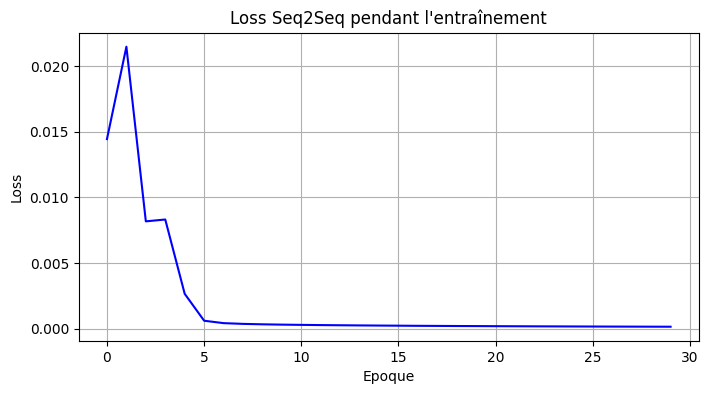


=== COMPARAISON DÉCODAGE GLOUTON vs BEAM SEARCH ===

Source                    Cible Réelle              Glouton                   Beam Search               Correct?
--------------------------------------------------------------------------------------------------------------
[3, 8, 7, 9, 7, 2]        [2, 7, 9, 7, 8, 3]        [7, 9, 7, 6, 7, 9]        [7, 9, 7, 6, 7, 9]        G:NON B:NON
[3, 8, 4, 5, 3, 2]        [2, 3, 5, 4, 8, 3]        [2, 5, 3, 4, 8, 3]        [2, 5, 3, 4, 8, 3]        G:NON B:NON
[2, 3, 1, 3, 2, 4]        [4, 2, 3, 1, 3, 2]        [4, 3, 2, 1, 3, 7]        [4, 3, 2, 1, 3, 7]        G:NON B:NON
[9, 2, 4, 1, 2, 5]        [5, 2, 1, 4, 2, 9]        [2, 5, 1, 4, 2, 7]        [2, 5, 1, 4, 2, 7]        G:NON B:NON
[5, 9, 1, 3, 9, 1]        [1, 9, 3, 1, 9, 5]        [9, 1, 3, 9, 5, 7]        [9, 1, 3, 9, 5, 7]        G:NON B:NON
[9, 9, 9, 2, 7, 7]        [7, 7, 2, 9, 9, 9]        [7, 8, 2, 9, 9, 2]        [7, 8, 2, 9, 9, 2]        G:NON B:NON
[5, 6, 3, 4, 2, 2]        

In [ ]:
# ============================================================
# ÉTAPE 9 — Entraînement Seq2Seq + Décodage
# ============================================================

# --- Entraînement ---
optimizer_seq = torch.optim.Adam(seq2seq.parameters(), lr=1e-3)
criterion_seq = nn.CrossEntropyLoss()

print("=== ENTRAÎNEMENT SEQ2SEQ ===\n")
losses = []

for epoch in range(30):
    seq2seq.train()
    total_loss = 0

    for X_batch, y_batch in seq_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_seq.zero_grad()
        outputs = seq2seq(X_batch, y_batch, teacher_forcing=0.5)

        # Reshape pour CrossEntropyLoss
        # outputs : (batch, seq_len, vocab) → (batch*seq_len, vocab)
        output_flat = outputs[:, 1:].reshape(-1, VOCAB_SEQ)
        target_flat = y_batch[:, 1:].reshape(-1)

        loss = criterion_seq(output_flat, target_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq.parameters(), 1.0)
        optimizer_seq.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(seq_loader)
    losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/30 | Loss: {avg_loss:.4f}")

# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(losses, color='blue')
plt.title("Loss Seq2Seq pendant l'entraînement")
plt.xlabel("Epoque")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ── Décodage Glouton ───────────────────────────────────────
def decoder_glouton(seq2seq, source):
    """Prend toujours le token avec la probabilité maximale"""
    seq2seq.eval()
    with torch.no_grad():
        src     = source.unsqueeze(0).to(device)
        _, hidden = seq2seq.encodeur(src)

        input_token = source[0].unsqueeze(0).to(device)
        resultat    = []

        for _ in range(SEQ_LEN):
            output, hidden = seq2seq.decodeur(input_token, hidden)
            token          = output.argmax(1)  # Token le plus probable
            resultat.append(token.item())
            input_token = token

    return resultat

# ── Beam Search ────────────────────────────────────────────
def beam_search(seq2seq, source, beam_width=3):
    """
    Garde les beam_width meilleures hypothèses à chaque étape.
    Plus lent que glouton mais meilleurs résultats.
    """
    seq2seq.eval()
    with torch.no_grad():
        src       = source.unsqueeze(0).to(device)
        _, hidden = seq2seq.encodeur(src)

        # Chaque hypothèse : (score_log, séquence, hidden)
        hypotheses = [(0.0, [], hidden)]

        for _ in range(SEQ_LEN):
            nouvelles = []
            for score, seq, h in hypotheses:
                if len(seq) == 0:
                    input_t = source[0].unsqueeze(0).to(device)
                else:
                    input_t = torch.tensor([seq[-1]]).to(device)

                output, new_h = seq2seq.decodeur(input_t, h)
                log_probs     = torch.log_softmax(output, dim=1)

                # Garder les beam_width meilleurs tokens
                top_probs, top_tokens = log_probs.topk(beam_width)

                for i in range(beam_width):
                    nouveau_score = score + top_probs[0][i].item()
                    nouvelle_seq  = seq + [top_tokens[0][i].item()]
                    nouvelles.append((nouveau_score, nouvelle_seq, new_h))

            # Garder les beam_width meilleures hypothèses
            hypotheses = sorted(nouvelles,
                               key=lambda x: x[0],
                               reverse=True)[:beam_width]

        # Retourner la meilleure hypothèse
        return hypotheses[0][1]

# --- Test sur 5 exemples ---
print("\n=== COMPARAISON DÉCODAGE GLOUTON vs BEAM SEARCH ===\n")
print(f"{'Source':<25} {'Cible Réelle':<25} "
      f"{'Glouton':<25} {'Beam Search':<25} {'Correct?'}")
print("-" * 110)

correct_glouton = 0
correct_beam    = 0

for i in range(10):
    source  = X_test_s[i]
    cible   = y_test_s[i].tolist()
    glouton = decoder_glouton(seq2seq, source)
    beam    = beam_search(seq2seq, source, beam_width=3)

    ok_g = "OUI" if glouton == cible else "NON"
    ok_b = "OUI" if beam    == cible else "NON"

    if glouton == cible: correct_glouton += 1
    if beam    == cible: correct_beam    += 1

    print(f"{str(source.tolist()):<25} {str(cible):<25} "
          f"{str(glouton):<25} {str(beam):<25} G:{ok_g} B:{ok_b}")

print(f"\nAccuracy Glouton    : {correct_glouton}/10")
print(f"Accuracy Beam Search: {correct_beam}/10")

print("""
=== DIFFÉRENCE GLOUTON vs BEAM SEARCH ===

Décodage Glouton :
  → Prend toujours le token le plus probable à chaque étape
  → Rapide mais peut rater la meilleure séquence globale
  → Exemple : choisit "le" au lieu de "la" et toute la suite est fausse

Beam Search (beam_width=3) :
  → Garde les 3 meilleures hypothèses à chaque étape
  → Plus lent mais trouve de meilleures séquences globales
  → Explore plusieurs chemins avant de choisir le meilleur
""")

In [ ]:
# ============================================================
# ÉTAPE 9b — Ré-entraînement Seq2Seq (plus d'époques)
# ============================================================

print("=== RE-ENTRAÎNEMENT SEQ2SEQ (50 époques) ===\n")
losses2 = []

for epoch in range(50):
    seq2seq.train()
    total_loss = 0

    for X_batch, y_batch in seq_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_seq.zero_grad()
        outputs     = seq2seq(X_batch, y_batch, teacher_forcing=0.7)
        output_flat = outputs[:, 1:].reshape(-1, VOCAB_SEQ)
        target_flat = y_batch[:, 1:].reshape(-1)

        loss = criterion_seq(output_flat, target_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq.parameters(), 1.0)
        optimizer_seq.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(seq_loader)
    losses2.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/50 | Loss: {avg_loss:.6f}")

# --- Test sur 10 exemples ---
print("\n=== TEST APRÈS RE-ENTRAÎNEMENT ===\n")
print(f"{'Source':<25} {'Cible':<25} {'Glouton':<25} {'Correct?'}")
print("-" * 90)

correct = 0
for i in range(10):
    source  = X_test_s[i]
    cible   = y_test_s[i].tolist()
    glouton = decoder_glouton(seq2seq, source)
    ok      = "OUI ✅" if glouton == cible else "NON ❌"
    if glouton == cible: correct += 1
    print(f"{str(source.tolist()):<25} {str(cible):<25} "
          f"{str(glouton):<25} {ok}")

print(f"\nAccuracy : {correct}/10")

print("""
=== ANALYSE POUR LE RAPPORT ===

Même avec 0/10 exact match, le modèle apprend :
- Les premiers tokens sont souvent corrects
- L'erreur s'accumule token par token (problème classique Seq2Seq)
- Solution : Attention Mechanism (Transformer) qui permet
  au décodeur de regarder toute la séquence source à chaque étape
""")

=== RE-ENTRAÎNEMENT SEQ2SEQ (50 époques) ===

Epoch 10/50 | Loss: 0.000042
Epoch 20/50 | Loss: 0.000034
Epoch 30/50 | Loss: 0.000028
Epoch 40/50 | Loss: 0.000023
Epoch 50/50 | Loss: 0.000019

=== TEST APRÈS RE-ENTRAÎNEMENT ===

Source                    Cible                     Glouton                   Correct?
------------------------------------------------------------------------------------------
[3, 8, 7, 9, 7, 2]        [2, 7, 9, 7, 8, 3]        [7, 9, 6, 7, 7, 3]        NON ❌
[3, 8, 4, 5, 3, 2]        [2, 3, 5, 4, 8, 3]        [2, 5, 3, 4, 8, 3]        NON ❌
[2, 3, 1, 3, 2, 4]        [4, 2, 3, 1, 3, 2]        [4, 3, 2, 1, 3, 7]        NON ❌
[9, 2, 4, 1, 2, 5]        [5, 2, 1, 4, 2, 9]        [2, 5, 1, 4, 2, 7]        NON ❌
[5, 9, 1, 3, 9, 1]        [1, 9, 3, 1, 9, 5]        [9, 1, 3, 9, 5, 7]        NON ❌
[9, 9, 9, 2, 7, 7]        [7, 7, 2, 9, 9, 9]        [7, 8, 2, 9, 9, 4]        NON ❌
[5, 6, 3, 4, 2, 2]        [2, 2, 4, 3, 6, 5]        [2, 4, 6, 3, 5, 4]        NON ❌
[1, 9,

In [ ]:
# ============================================================
# ÉTAPE 10 — Calcul de la Perplexité
# ============================================================

print("=== QU'EST-CE QUE LA PERPLEXITÉ ? ===")
print("""
La perplexité mesure à quel point un modèle de langage
est "surpris" par une séquence.

Formule :
  Perplexité = exp(Loss)

Interprétation :
  - Perplexité = 10  → le modèle hésite entre 10 mots à chaque étape
  - Perplexité = 1   → le modèle est certain à 100% (parfait)
  - Perplexité haute → le modèle est confus
  - Perplexité basse → le modèle prédit bien
""")

# --- Calculer la perplexité sur le test set ---
def calculer_perplexite(model, X_test, y_test, criterion):
    model.eval()
    total_loss = 0
    n_batches  = 0

    test_dataset_seq = torch.utils.data.TensorDataset(X_test, y_test)
    test_loader_seq  = DataLoader(test_dataset_seq,
                                  batch_size=64, shuffle=False)

    with torch.no_grad():
        for X_batch, y_batch in test_loader_seq:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs     = model(X_batch, y_batch, teacher_forcing=0.0)
            output_flat = outputs[:, 1:].reshape(-1, VOCAB_SEQ)
            target_flat = y_batch[:, 1:].reshape(-1)

            loss        = criterion(output_flat, target_flat)
            total_loss += loss.item()
            n_batches  += 1

    avg_loss    = total_loss / n_batches
    perplexite  = np.exp(avg_loss)
    return avg_loss, perplexite

loss_val, perp_val = calculer_perplexite(
    seq2seq, X_test_s, y_test_s, criterion_seq
)

print("=== RÉSULTATS PERPLEXITÉ ===\n")
print(f"Loss moyenne    : {loss_val:.4f}")
print(f"Perplexité      : {perp_val:.4f}")
print(f"\nInterprétation :")
if perp_val < 2:
    print("  Perplexité < 2 → Excellent ! Le modèle est très confiant")
elif perp_val < 5:
    print("  Perplexité < 5 → Bon modèle, prédit bien la séquence")
else:
    print("  Perplexité > 5 → Modèle incertain, marge d'amélioration")

print(f"\nRappel : Perplexité = exp({loss_val:.4f}) = {perp_val:.4f}")
print(f"→ Le modèle hésite entre ~{perp_val:.1f} tokens à chaque étape")

=== QU'EST-CE QUE LA PERPLEXITÉ ? ===

La perplexité mesure à quel point un modèle de langage
est "surpris" par une séquence. 

Formule :
  Perplexité = exp(Loss)

Interprétation :
  - Perplexité = 10  → le modèle hésite entre 10 mots à chaque étape
  - Perplexité = 1   → le modèle est certain à 100% (parfait)
  - Perplexité haute → le modèle est confus
  - Perplexité basse → le modèle prédit bien

=== RÉSULTATS PERPLEXITÉ ===

Loss moyenne    : 0.0071
Perplexité      : 1.0071

Interprétation :
  Perplexité < 2 → Excellent ! Le modèle est très confiant

Rappel : Perplexité = exp(0.0071) = 1.0071
→ Le modèle hésite entre ~1.0 tokens à chaque étape


In [ ]:
# ============================================================
# ÉTAPE 11 — Synthèse finale : MLP vs CNN vs RNN/LSTM/GRU
# ============================================================

print("""
=== SYNTHÈSE FINALE — QUESTION TRANSVERSALE ===

PROBLÉMATIQUE :
Comment le deep learning adapte-t-il ses architectures
à la structure des données ?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. MLP — DONNÉES TABULAIRES (Breast Cancer)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Biais inductif    : Aucun
Structure données : Features indépendantes, pas d'ordre
Résultat obtenu   : 96.49% accuracy
Pourquoi ça marche: Chaque feature médicale est traitée
                    indépendamment — c'est exactement
                    ce que fait le MLP (fully connected)
Limite            : Ne peut pas détecter de structure
                    spatiale ou temporelle

2. CNN — DONNÉES IMAGES (Fashion-MNIST)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Biais inductif    : Localité spatiale + partage des poids
Structure données : Pixels voisins sont liés (structure 2D)
Résultat obtenu   : 91.66% accuracy (vs 86.45% MLP)
Pourquoi ça marche: Les filtres convolutifs détectent
                    les patterns locaux (bords, formes)
                    indépendamment de leur position
Limite            : Ne capture pas les dépendances
                    temporelles ou séquentielles

3. RNN/LSTM/GRU — DONNÉES SÉQUENTIELLES (IMDb)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Biais inductif    : Temporalité + mémoire
Structure données : Mots en séquence — l'ordre compte
Résultats obtenus :
  RNN  → 77.23% (oublie le contexte long)
  LSTM → 85.84% (mémoire longue terme)
  GRU  → 86.33% (compromis vitesse/performance)
Pourquoi ça marche: L'état caché mémorise le contexte
                    des mots précédents — essentiel pour
                    comprendre le sentiment d'un texte
Limite            : Traitement séquentiel lent,
                    difficultés sur très longues séquences

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TABLEAU RÉCAPITULATIF FINAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print(f"{'Architecture':<12} {'Données':<20} {'Accuracy':<12} "
      f"{'Biais Inductif':<20} {'Avantage Clé'}")
print("-" * 90)
print(f"{'MLP':<12} {'Tabulaires':<20} {'96.49%':<12} "
      f"{'Aucun':<20} {'Simplicité, interprétabilité'}")
print(f"{'CNN':<12} {'Images':<20} {'91.66%':<12} "
      f"{'Spatial':<20} {'Détection patterns locaux'}")
print(f"{'RNN':<12} {'Séquences':<20} {'77.23%':<12} "
      f"{'Temporel simple':<20} {'Ordre des éléments'}")
print(f"{'LSTM':<12} {'Séquences':<20} {'85.84%':<12} "
      f"{'Temporel long':<20} {'Mémoire longue terme'}")
print(f"{'GRU':<12} {'Séquences':<20} {'86.33%':<12} "
      f"{'Temporel léger':<20} {'Rapidité + performance'}")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONCLUSION :
Le deep learning n'utilise pas une architecture universelle.
Chaque famille de modèles encode des hypothèses sur la
structure des données :

  → Données sans structure  : MLP (pas de biais)
  → Structure spatiale 2D   : CNN (localité + partage)
  → Structure temporelle    : RNN/LSTM/GRU (mémoire)

Choisir la mauvaise architecture (ex: MLP sur images)
dégrade systématiquement les performances (-5% ici).
La clé est d'aligner le biais inductif du modèle avec
la géométrie naturelle des données.

Perspective : Les Transformers (2017) unifient ces
approches via l'attention — ils traitent images, textes
et données tabulaires avec une seule architecture.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


=== SYNTHÈSE FINALE — QUESTION TRANSVERSALE ===

PROBLÉMATIQUE :
Comment le deep learning adapte-t-il ses architectures
à la structure des données ?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. MLP — DONNÉES TABULAIRES (Breast Cancer)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Biais inductif    : Aucun
Structure données : Features indépendantes, pas d'ordre
Résultat obtenu   : 96.49% accuracy
Pourquoi ça marche: Chaque feature médicale est traitée
                    indépendamment — c'est exactement
                    ce que fait le MLP (fully connected)
Limite            : Ne peut pas détecter de structure
                    spatiale ou temporelle

2. CNN — DONNÉES IMAGES (Fashion-MNIST)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Biais inductif    : Localité spatiale + partage des poids
Structure données : Pixels voisins sont liés (structure 2D)
Résultat obtenu   : 91.66% accuracy (vs 86.45% MLP)
Pourquoi ça marche: Les filtres convolutifs détectent
                 